<a href="https://colab.research.google.com/github/Asmitx026/AI-Lab/blob/main/assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q. Iris Dataset Classification using Support Vector Machines (SVC)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
iris = sns.load_dataset('iris')
print("\nDataset Shape:", iris.shape)
print("\nFirst 5 Rows:")
display(iris.head())


Dataset Shape: (150, 5)

First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = iris[[
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width'
]]
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [ ]:
model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    )
)
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(probability=True, random_state=42))])

In [ ]:
y_pred=model.predict(X_test)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))
print("Number of Support Vectors:",len(model.named_steps['svc'].support_))

accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Training Samples: 120
Testing Samples: 30
Number of Support Vectors: 47
Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



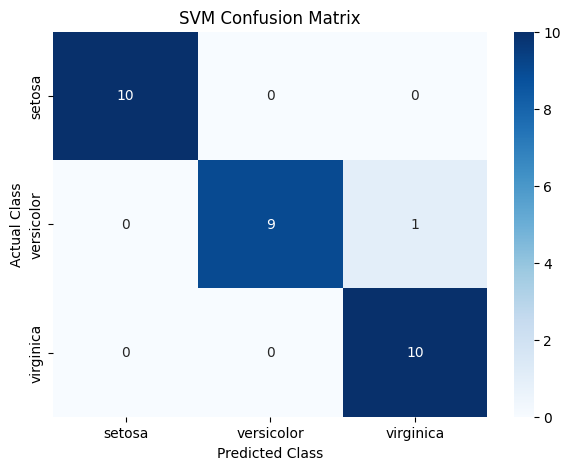

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=model.named_steps['svc'].classes_,
    yticklabels=model.named_steps['svc'].classes_
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [ ]:
new_flower = [[5.1,3.5,1.4,0.2]]
print(f"New Flower: {new_flower}")
y_pred_new = model.predict(new_flower)

New Flower: [[5.1, 3.5, 1.4, 0.2]]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("Predicted Species:",y_pred_new[0])

Predicted Species: setosa


Text(0.5, 1.0, 'Iris Dataset - SVM Feature Visualization')

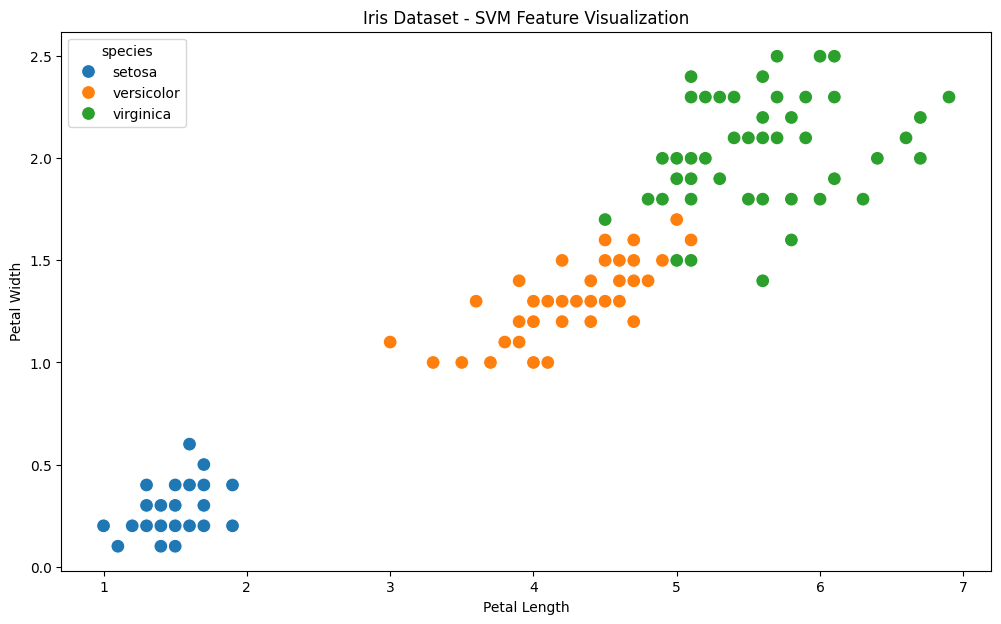

In [ ]:
plt.figure(figsize=(12,7))
sns.scatterplot(
    data = iris,
    x = 'petal_length',
    y = 'petal_width',
    hue = 'species',
    s=100
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset - SVM Feature Visualization")